In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

c:\Users\Windows 10\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


### Extract Data

In [2]:
df_returns = pd.read_csv(r'C:\Users\Windows 10\OneDrive\Desktop\Coding\Stat Comp\Project\Data\mag7_nasdaq_returns.csv')
df_returns.drop(columns=['Unnamed: 0'], inplace=True)
df_returns['Date'] = pd.to_datetime(df_returns['Date'])
df_returns = df_returns.set_index('Date')
df_returns.head()

,AAPL,AMZN,WTI_Crude_Oil,Dollar_Index,COMEX_Gold,GOOGL,META,MSFT,NVDA,Treasury_Inflation,TSLA,Nasdaq,VIX_Fear_Index
Date,,,,,,,,,,,,,
2021-01-05,0.012364,0.010004,0.048509,-0.004895,0.004114,0.008064,0.007548,0.000965,0.022210,-0.000313,0.007317,0.009490,-0.060437
2021-01-06,-0.033662,-0.024897,0.014020,0.001006,-0.023455,-0.009868,-0.028269,-0.025929,-0.058953,-0.002975,0.028390,-0.006098,-0.010655
2021-01-07,0.034123,0.007577,0.003950,0.003351,0.002832,0.029869,0.020622,0.028457,0.057830,-0.000628,0.079447,0.025641,-0.107698
2021-01-08,0.008631,0.006496,0.027740,0.003006,-0.040893,0.013239,-0.004354,0.006093,-0.005040,-0.003928,0.078403,0.010293,-0.036209
2021-01-11,-0.023249,-0.021519,0.000191,0.004883,0.008451,-0.023106,-0.040102,-0.009699,0.025967,-0.002130,-0.078214,-0.012540,0.116883


### Train Data

In [3]:
# 'Date' is already the index of df_returns, so drop only the target column
X = df_returns.drop(columns=['Nasdaq'])
y = df_returns['Nasdaq']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

### Modeling

In [4]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Test & Predict

In [5]:
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

### Evaluation Metrics

In [6]:
r2 = r2_score(y_test, y_pred_test)
mae = mean_absolute_error(y_test, y_pred_test)
mse = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
mape = np.mean(np.abs((y_test - y_pred_test) / y_test)) * 100
wape = np.sum(np.abs(y_test - y_pred_test)) / np.sum(np.abs(y_test)) * 100

print("-" * 30)
print(f"Result of MLR")
print("-" * 30)
print(f"MAE:  {mae:.5f}")
print(f"MSE:  {mse:.5f}")
print(f"RMSE: {rmse:.5f}")
print(f"MAPE: {mape:.2f}%")
print(f"WAPE: {wape:.2f}%")
print(f"R-squared:  {r2:.4f}")

------------------------------
Result of MLR
------------------------------
MAE:  0.00254
MSE:  0.00001
RMSE: 0.00329
MAPE: inf%
WAPE: 26.00%
R-squared:  0.9533


In [7]:
# Create a DataFrame to analyze errors
df = pd.DataFrame({'Actual': y_test, 'Forecast': y_pred_test})
df['Absolute_Error'] = abs(df['Actual'] - df['Forecast'])
df['APE'] = (df['Absolute_Error'] / df['Actual']) * 100

# Sort by APE to find the top 10 instances with the highest percentage error
print(df.sort_values(by='APE', ascending=False).head(10))

              Actual  Forecast  Absolute_Error          APE
Date                                                       
2025-01-09  0.000000 -0.000336        0.000336          inf
2025-05-26  0.000000  0.000085        0.000085          inf
2025-07-04  0.000000 -0.000219        0.000219          inf
2025-05-09  0.000043  0.003335        0.003291  7571.854110
2025-09-10  0.000300 -0.005964        0.006264  2085.996238
2025-05-19  0.000227 -0.001991        0.002218   976.982913
2025-07-18  0.000479  0.004167        0.003688   770.297917
2025-02-18  0.000724 -0.004558        0.005281   729.922027
2025-08-18  0.000314 -0.001251        0.001565   498.521008
2025-04-07  0.000992 -0.002332        0.003324   334.975816


### Regression Line Prediction

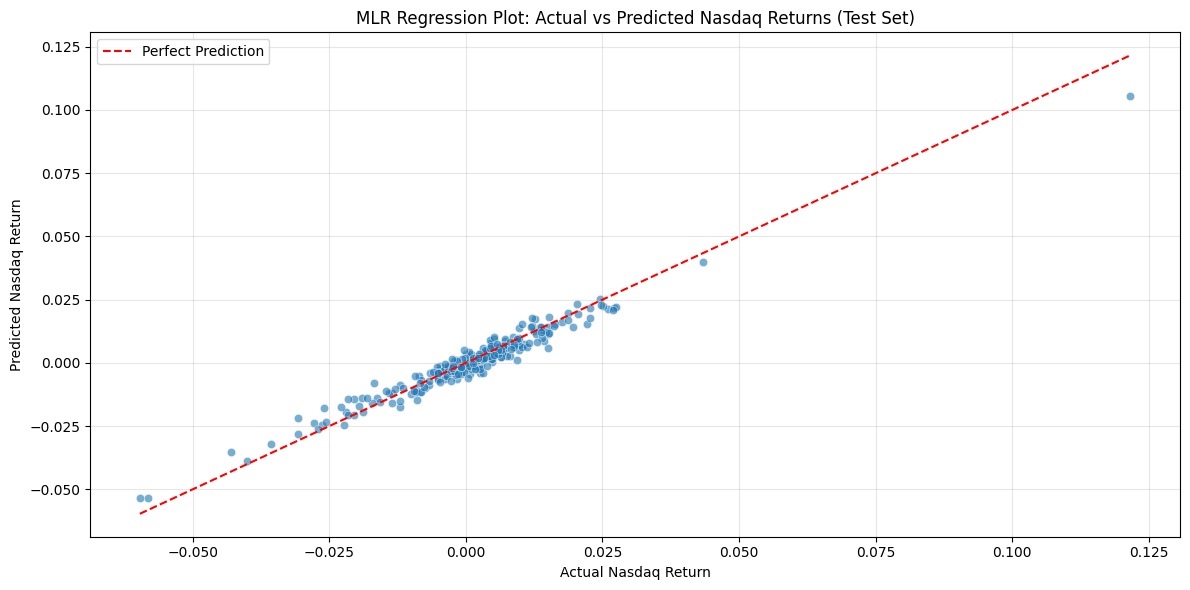

In [8]:
# Combine actual and predicted test values into a DataFrame for easier plotting
df_regression = pd.DataFrame({
    'Actual Nasdaq Return': y_test,
    'Predicted Nasdaq Return': y_pred_test
}).dropna()

plt.figure(figsize=(12, 6))
sns.scatterplot(x='Actual Nasdaq Return', y='Predicted Nasdaq Return', data=df_regression, alpha=0.6)

# Add a perfect prediction line (y=x)
min_val = min(df_regression['Actual Nasdaq Return'].min(), df_regression['Predicted Nasdaq Return'].min())
max_val = max(df_regression['Actual Nasdaq Return'].max(), df_regression['Predicted Nasdaq Return'].max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction')

plt.title('MLR Regression Plot: Actual vs Predicted Nasdaq Returns (Test Set)')
plt.xlabel('Actual Nasdaq Return')
plt.ylabel('Predicted Nasdaq Return')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Actual vs Predicted Nasdaq Returns by time

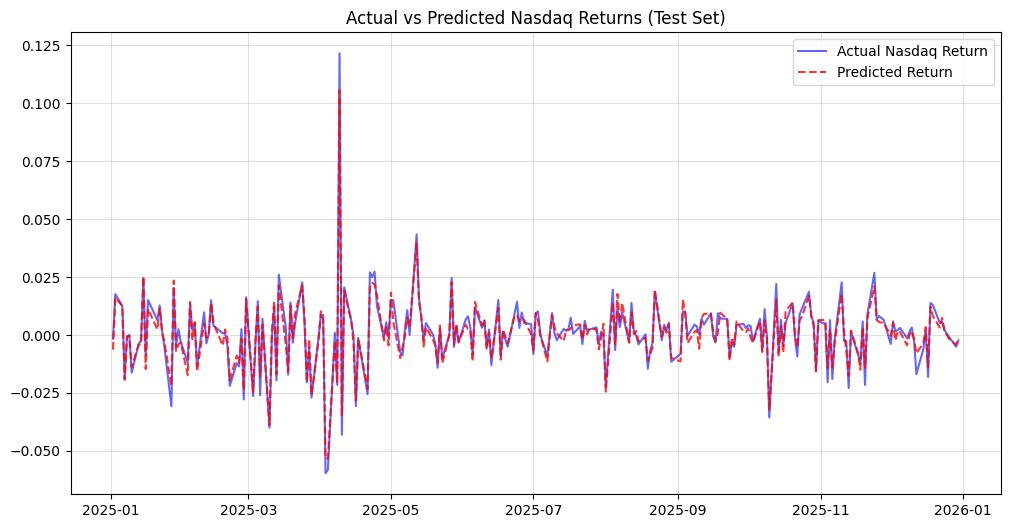

In [9]:
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label='Actual Nasdaq Return', color='blue', alpha=0.6)
plt.plot(y_test.index, y_pred_test, label='Predicted Return', color='red', linestyle='--', alpha=0.8)
plt.title('Actual vs Predicted Nasdaq Returns (Test Set)')
plt.legend()
plt.grid(True, alpha=0.4)

### Distribution of Actual vs. Predicted Nasdaq Returns

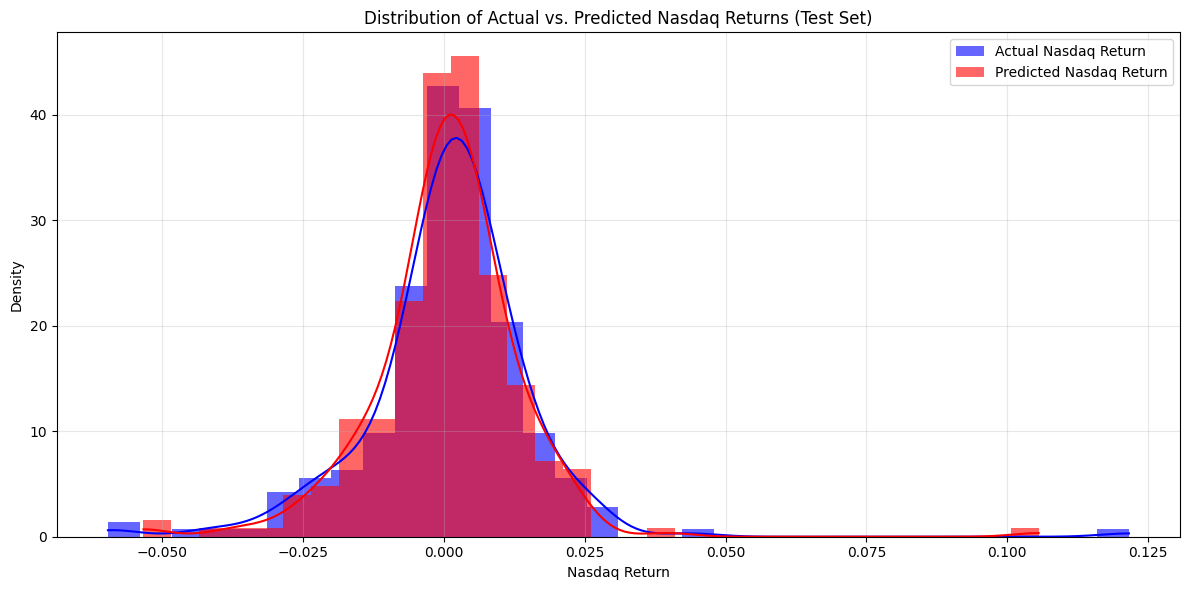

In [10]:
plt.figure(figsize=(12,6))
sns.histplot(y_test, kde=True, color='blue', label='Actual Nasdaq Return', alpha=0.6, stat='density', linewidth=0)
sns.histplot(y_pred_test, kde=True, color='red', label='Predicted Nasdaq Return', alpha=0.6, stat='density', linewidth=0)
plt.title('Distribution of Actual vs. Predicted Nasdaq Returns (Test Set)')
plt.xlabel('Nasdaq Return')
plt.ylabel('Density')
plt.legend()
plt.grid(True, alpha=00.3)
plt.tight_layout()
plt.show()

### Coefficients of Feature Impact

In [11]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})
# Sort coefficients by absolute value in descending order
coef_df = coef_df.sort_values(by='Coefficient', ascending=False)

print("\nCoefficients of each feature in descending order:")
print(coef_df)


Coefficients of each feature in descending order:
               Feature  Coefficient
0                 AAPL     0.166259
7                 MSFT     0.130536
1                 AMZN     0.102348
8                 NVDA     0.097482
5                GOOGL     0.072733
10                TSLA     0.057108
6                 META     0.052844
9   Treasury_Inflation     0.043361
2        WTI_Crude_Oil     0.005021
4           COMEX_Gold    -0.010979
11      VIX_Fear_Index    -0.024247
3         Dollar_Index    -0.144834


C:\Temp\ipykernel_24864\2230758502.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='viridis')


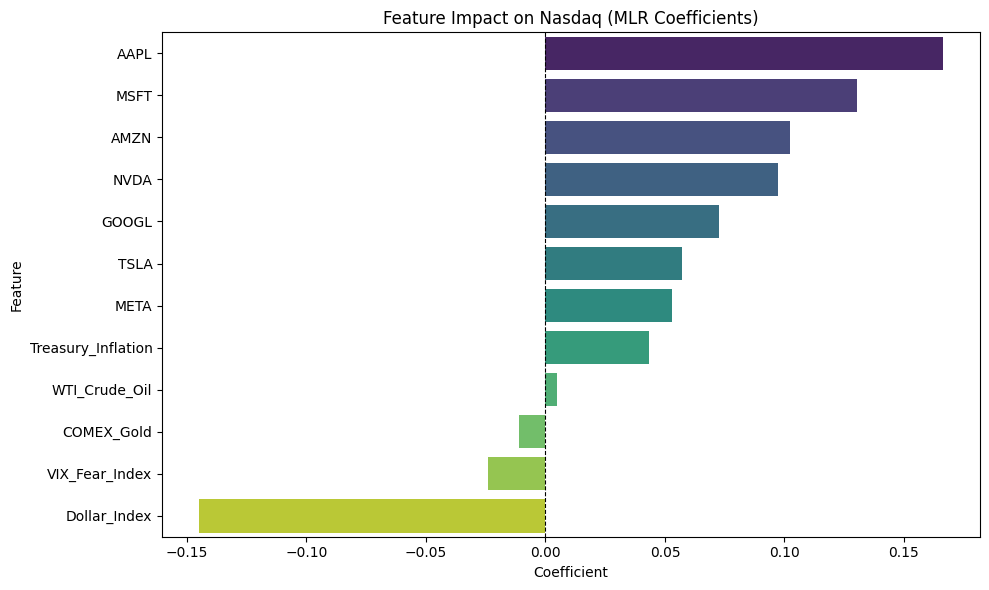

In [12]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='viridis')
plt.title('Feature Impact on Nasdaq (MLR Coefficients)')
plt.axvline(0, color='black', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.show()